# Fast F1 and Ergast Race Data Analysis and Model Training
In order to output the best pit stop strategy for minimizing overall race time, we first need to train a model that can predict race times the most accurately.

### 0. Import and Install

In [73]:
from matplotlib import pyplot as plt
import fastf1
import fastf1.plotting
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
import statsmodels.api as sm
import numpy as np
from fastf1.ergast import Ergast
import statsmodels.api as sm
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

We will first make a few requests to see some information that we are interested in. For this exercise I'm just going to pick from the 2020 Bahrain GP.

In [74]:
ergast = Ergast()

# Set up the session
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')
session = fastf1.get_session(2020, 'Bahrain', 'Race')
session.load()

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
req            INFO 	Data has been written to cache!
events      WARNING 	Correcting user input 'Bahrain' to 'Bahrain Grand Prix'
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.4.4]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached d

In [75]:
laps = session.laps

# Load the box laps.
pit_data = laps.pick_box_laps()
pit_data.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:36:04.877000,GAS,10,0 days 00:02:27.729000,1.0,1.0,NaT,0 days 00:36:03.087000,NaT,0 days 00:01:15.022000,...,False,AlphaTauri,0 days 00:33:36.921000,2020-11-29 14:13:36.973,15,8.0,False,,False,False
1,0 days 01:58:35.913000,GAS,10,NaT,2.0,2.0,0 days 01:55:23.556000,NaT,NaT,0 days 00:01:17.873000,...,True,AlphaTauri,0 days 01:55:00.402000,2020-11-29 15:35:00.454,1,9.0,False,,False,False
24,0 days 02:41:03.636000,GAS,10,0 days 00:01:39.369000,25.0,2.0,NaT,0 days 02:41:01.961000,0 days 00:00:30.827000,0 days 00:00:42.114000,...,True,AlphaTauri,0 days 02:39:24.267000,2020-11-29 16:19:24.319,1,5.0,False,,False,False
25,0 days 02:42:59.135000,GAS,10,0 days 00:01:55.499000,26.0,3.0,0 days 02:41:26.465000,NaT,0 days 00:00:51.024000,0 days 00:00:41.102000,...,True,AlphaTauri,0 days 02:41:03.636000,2020-11-29 16:21:03.688,1,9.0,False,,False,False
57,0 days 00:35:49.988000,PER,11,0 days 00:02:12.787000,1.0,1.0,NaT,0 days 00:35:47.466000,NaT,0 days 00:01:05.892000,...,False,Racing Point,0 days 00:33:36.921000,2020-11-29 14:13:36.973,15,4.0,False,,False,False


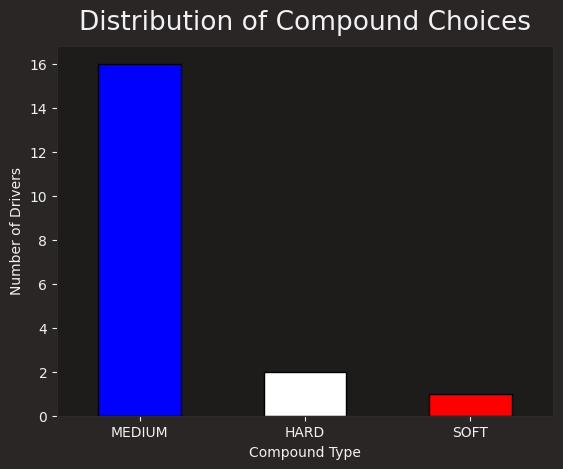

In [76]:
# Let's look at the graph of how many ppl picked each compound for the first stint of the race just for shiggles!
# Filter for stint 1 only
stint_one = pit_data[pit_data['Stint'] == 1.0]
compound_counts = stint_one['Compound'].value_counts()

compound_counts.plot(kind='bar', color=['blue', 'white', 'red'], edgecolor='black')

plt.title('Distribution of Compound Choices')
plt.xlabel('Compound Type')
plt.ylabel('Number of Drivers')
plt.xticks(rotation=0)
plt.show()

What about **tire deg**? It's insanely important to understand. Let's graph the tire life of each compound over this race.

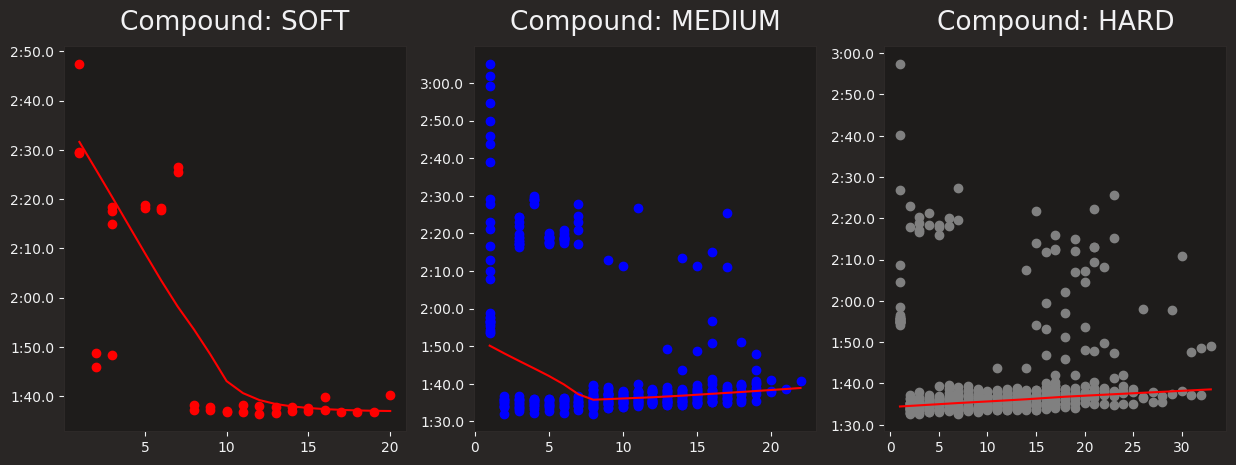

In [89]:
# Let's analyze them together.
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

compounds = ['SOFT', 'MEDIUM', 'HARD']
colors = ['red', 'blue', 'gray']

for i in range(len(compounds)):
    stints = laps[["Driver", "Stint", "Compound", "LapNumber", "LapTime"]]

    stints.loc[:,'StintLapNumber'] = stints.groupby(["Driver", "Stint"]).cumcount() + 1
    comp_data = stints[stints['Compound'] == compounds[i]]
    comp_data = comp_data.dropna()
    comp_data.loc[:, 'LapTimeSec'] = pd.to_timedelta(comp_data['LapTime']).dt.total_seconds()

    # Graph number of laps vs laptime
    axs[i].scatter(comp_data["StintLapNumber"], comp_data["LapTime"], color=colors[i])

    # We'll use LOWESS
    lowess = sm.nonparametric.lowess
    y_smooth = lowess(comp_data["LapTimeSec"], comp_data["StintLapNumber"], frac=0.8)  # `frac` determines smoothing

    # Extract the smoothed x and y
    x_smooth = y_smooth[:, 0]
    y_smooth = y_smooth[:, 1]
    y_smooth_timedelta = pd.to_timedelta(y_smooth, unit='s')
    axs[i].plot(x_smooth, y_smooth_timedelta, label='LOWESS Smoothed', color='red')
    axs[i].set_title(f"Compound: {compounds[i]}")

Looks just as how we expected. Hards are more durable while softs are faster but degrade super fast over time.